In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

items_raw=pd.read_csv("items.csv")
customers_raw=pd.read_csv("customers.csv")
orders_raw=pd.read_csv("orders.csv")
order_item_raw=pd.read_csv("order_item.csv", index_col=0)
# data copying
items=items_raw.copy()
customers=customers_raw.copy()
orders=orders_raw.copy()
order_items=order_item_raw.copy()

,gender,customer_count
0,Female,203
1,Male,196
2,Agender,13
3,Genderfluid,12
4,Non-binary,7
5,Polygender,6
6,Bigender,5
7,Genderqueer,5


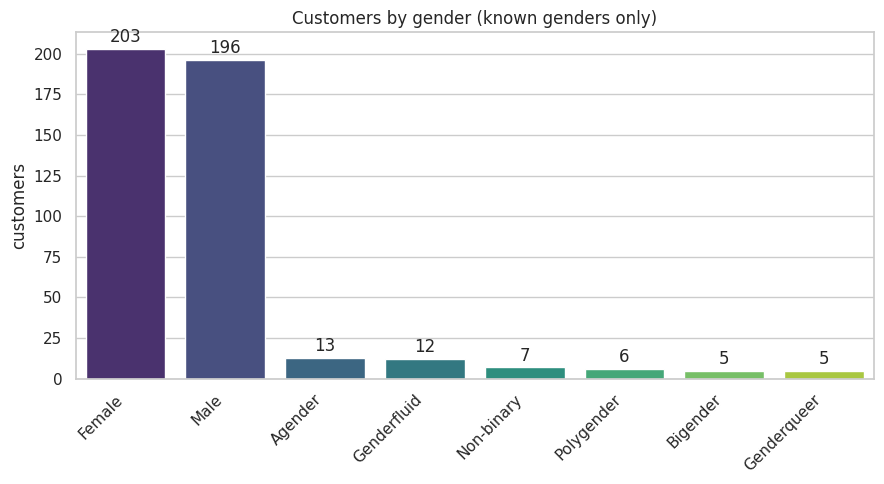

In [3]:
# --- Analysis 1: Customer Analysis ---
sns.set_theme(style='whitegrid')

gender_imputed_ids = set(customers.loc[customers['gender'].isna(), 'id'])
# exclude mode-imputed genders - the fill would add 53 customers to the majority category
gender_real = customers[~customers['id'].isin(gender_imputed_ids)]

gender_counts = (gender_real['gender'].value_counts()
                 .rename_axis('gender')
                 .reset_index(name='customer_count'))
display(gender_counts)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(gender_counts, x='gender', y='customer_count',
            hue='gender', palette='viridis', legend=False, ax=ax)
for container in ax.containers:
    ax.bar_label(container, padding=2)
ax.set_title('Customers by gender (known genders only)')
ax.set_xlabel(''); ax.set_ylabel('customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()